<a href="https://colab.research.google.com/github/sergioGarcia91/SeismicUP/blob/main/01_EDA_inicial_SGC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este cuaderno integra y normaliza los catálogos sísmicos descargados del Servicio Geológico Colombiano (SGC - https://bdrsnc.sgc.gov.co/paginas1/catalogo) y realiza un análisis preliminar de la distribución espacial de los eventos en el área del Campo Colorado. Se establece un punto central de referencia y, a partir de él, se examina la ubicación relativa de los sismos para identificar patrones de concentración y posibles vacíos de registro.

# Inicio

In [ ]:
!git clone https://github.com/sergioGarcia91/SeismicUP.git

Cloning into 'SeismicUP'...
remote: Enumerating objects: 424, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 424 (delta 71), reused 0 (delta 0), pack-reused 301 (from 1)
Receiving objects: 100% (424/424), 20.74 MiB | 31.79 MiB/s, done.
Resolving deltas: 100% (219/219), done.


In [ ]:
# para incluir la libreria clonada
import sys
sys.path.append("/content/SeismicUP")

import seismicup as sup

In [ ]:
!pip -q install python-calamine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 933.6/933.6 kB 11.6 MB/s eta 0:00:00


In [ ]:
!pip3 install contextily

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
import os
import re
import contextily as cx #para el basemap en geopandas
import xyzservices.providers as xyz #para escoger el basemap
import seismicup as sup
import urllib.request
import matplotlib.font_manager as fm

from matplotlib.colors import LogNorm # para la escala logaritmica de los colores
from matplotlib.ticker import LogFormatter, LogLocator # escala log
from scipy import stats # regresion lineal

# Conectar al Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Cambiar Fuente

In [ ]:
sup.plots.get_TimesNewRoman_font()

# Paths

In [ ]:
path_save_figures = '/content/drive/MyDrive/Contratos/20250801_UIS_CO2/Notebooks/Figuras_01_EDA'

In [ ]:
path_shape_municipios = '/content/drive/MyDrive/Contratos/20250801_UIS_CO2/SIG/MGN2020_MPIO_POLITICO'

In [ ]:
path_datasets = '/content/SeismicUP/Datasets_'

os.listdir(path_datasets)

['Cat_sis_SGC_mar2018_2024',
 'Cat_sis_SGC_TECTO_feb2014_2024',
 'README.md',
 'Cat_sis_SGC_jun1993_feb2018',
 'Cat_sis_SGC_LBG_jun1993_2021']

# Cargar catalogos

In [ ]:
lista_catalogos = ['Cat_sis_SGC_jun1993_feb2018',
                   'Cat_sis_SGC_mar2018_2024',
                   'Cat_sis_SGC_TECTO_feb2014_2024',
                   'Cat_sis_SGC_LBG_jun1993_2021']

for i in lista_catalogos:
  cantidad_archivos = len(os.listdir(os.path.join(path_datasets, i)))
  print(f'{i} = ', cantidad_archivos)

Cat_sis_SGC_jun1993_feb2018 =  26
Cat_sis_SGC_mar2018_2024 =  8
Cat_sis_SGC_TECTO_feb2014_2024 =  13
Cat_sis_SGC_LBG_jun1993_2021 =  29


In [ ]:
df_general = pd.DataFrame(columns=['Fecha-Hora UTC',
                                   'Latitud', # grados
                                   'Longitud', # grados
                                   'Profundidad [km]',
                                   'Magnitud',
                                   'Tipo Magnitud',
                                   'Error Latitud [km]',
                                   'Error Longitud [km]',
                                   'Error Profundidad [km]',
                                   'Numero de Fases',
                                   'RMS [seg]',
                                   'Gap', # grados
                                   'Departamento',
                                   'Municipio',
                                   ])

df_general.head()

,Fecha-Hora UTC,Latitud,Longitud,Profundidad [km],Magnitud,Tipo Magnitud,Error Latitud [km],Error Longitud [km],Error Profundidad [km],Numero de Fases,RMS [seg],Gap,Departamento,Municipio


## Catalogo SGC 1

In [ ]:
lista_catalogos

['Cat_sis_SGC_jun1993_feb2018',
 'Cat_sis_SGC_mar2018_2024',
 'Cat_sis_SGC_TECTO_feb2014_2024',
 'Cat_sis_SGC_LBG_jun1993_2021']

In [ ]:
path_catalogo = os.path.join(path_datasets, 'Cat_sis_SGC_jun1993_feb2018')
os.listdir(path_catalogo)

df_SGC_1 = df_general.copy()

for i in os.listdir(path_catalogo)[:]:
  if i.endswith('.xlsx'):
    print('-----'*3)
    print('File: ', i)
    print('-----'*3)
    df_temp_1 = sup.io.crear_catalogo_SGC_1(path_catalogo=path_catalogo,
                                            file_excel=i)

    df_SGC_1 = pd.concat([df_SGC_1, df_temp_1], ignore_index=True)
    df_SGC_1.reset_index(drop=True, inplace=True)

    del df_temp_1


---------------
File:  Cat_sis_SGC_2012.xlsx
---------------

['CUNDINAMARCA' 'SANTANDER' 'ANTIOQUIA' 'CESAR' 'BOLIVAR'
 'NORTE DE SANTANDER' 'BOYACA' 'TOLIMA' 'VALLE DEL CAUCA' 'ATLANTICO'
 'CALDAS' 'META' 'ARAUCA' 'CORDOBA' 'LA GUAJIRA' 'CASANARE' 'MAGDALENA'
 'HUILA' 'RISARALDA' 'SUCRE' 'QUINDIO']

['SUTATAUSA' 'LANDAZURI' 'VILLANUEVA' 'JORDAN' 'LOS SANTOS' 'VALDIVIA'
 'GAMARRA' 'CANTAGALLO' 'NECHI' 'LA ESPERANZA' 'GALAN' 'HATO'
 'SANTA HELENA DEL OPON' 'RIONEGRO' 'PAUNA' 'CUCUNUBA'
 'LA JAGUA DE IBIRICO' 'SAN VICENTE DE CHUCURI' 'BETULIA' 'ZAPATOCA'
 'LEBRIJA' 'OTANCHE' 'UBATE' 'GUAMO' 'CEPITA' 'SURATA' 'EL CARMEN'
 'CALDAS' 'BETANIA' 'LA BELLEZA' 'LENGUAZAQUE' 'AGUSTIN CODAZZI'
 'SAN DIEGO' 'OBANDO' 'VILLA DEL ROSARIO' 'SIMITI' 'GUICAN' 'SANTA ISABEL'
 'SEGOVIA' 'GUACA' 'BOLIVAR' 'GAMBITA' 'EL PENON' 'PUERTO BOYACA'
 'SAN MIGUEL DE SEMA' 'SUCRE' 'MONTECRISTO' 'REPELON' 'BARRANCABERMEJA'
 'SAN MARTIN' 'BARBOSA' 'PISVA' 'SABANA DE TORRES' 'RIOBLANCO' 'CUBARA'
 'MONTEBELLO' 'PUERTO B

/tmp/ipython-input-915494741.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_SGC_1 = pd.concat([df_SGC_1, df_temp_1], ignore_index=True)



['SANTANDER' 'TOLIMA' 'CUNDINAMARCA' 'ANTIOQUIA' 'NORTE DE SANTANDER'
 'ARAUCA' 'BOYACA' 'CESAR' 'HUILA' 'CALDAS' 'BOLIVAR' 'META' 'CORDOBA'
 'VALLE DEL CAUCA' 'CASANARE' 'SUCRE' 'QUINDIO' 'LA GUAJIRA' 'RISARALDA'
 'MAGDALENA' 'ATLANTICO']

['ZAPATOCA' 'AMBALEMA' 'LOS SANTOS' 'BETULIA' 'LANDAZURI'
 'SAN VICENTE DE CHUCURI' 'CUCUNUBA' 'EL CARMEN' 'CEPITA' 'LA PAZ'
 'VILLANUEVA' 'ITUANGO' 'JESUS MARIA' 'SIMIJACA' 'CAMPAMENTO' 'BUCARASICA'
 'SARAVENA' 'CERRITO' 'PIEDECUESTA' 'SAN CAYETANO' 'TUNUNGUA'
 'SAN ALBERTO' 'BARICHARA' 'SUCRE' 'EL PLAYON' 'TELLO' 'JORDAN' 'GUICAN'
 'RONCESVALLES' 'CUBARA' 'MALAGA' 'NORCASIA' 'SAN ANDRES'
 'AGUSTIN CODAZZI' 'SANTA ROSA DEL SUR' 'MOLAGAVITA' 'ALVARADO'
 'SAN PABLO DE BORBUR' 'COLOMBIA' 'SAN JUAN DE ARAMA' 'BRICENO' 'VELEZ'
 'BOLIVAR' 'SANTA HELENA DEL OPON' 'MATANZA' 'OTANCHE' 'PUENTE NACIONAL'
 'YONDO' 'PUEBLO NUEVO' 'ALTOS DEL ROSARIO' 'MONGUI' 'SIBATE' 'PAUNA'
 'GRANADA' 'OBANDO' 'SAN EDUARDO' 'RONDON' 'FUQUENE' 'GONZALEZ'
 'ZETAQUIRA' 'PUEBLO B

In [ ]:
df_SGC_1['Catalogo'] = 'SGC 1'
df_SGC_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145061 entries, 0 to 145060
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Fecha-Hora UTC          145061 non-null  object 
 1   Latitud                 145061 non-null  float64
 2   Longitud                145061 non-null  float64
 3   Profundidad [km]        145061 non-null  float64
 4   Magnitud                145061 non-null  float64
 5   Tipo Magnitud           145061 non-null  object 
 6   Error Latitud [km]      144927 non-null  float64
 7   Error Longitud [km]     144927 non-null  float64
 8   Error Profundidad [km]  144927 non-null  float64
 9   Numero de Fases         145061 non-null  object 
 10  RMS [seg]               144927 non-null  float64
 11  Gap                     144927 non-null  object 
 12  Departamento            145061 non-null  object 
 13  Municipio               145061 non-null  object 
 14  Catalogo            

In [ ]:
df_SGC_1.head()

,Fecha-Hora UTC,Latitud,Longitud,Profundidad [km],Magnitud,Tipo Magnitud,Error Latitud [km],Error Longitud [km],Error Profundidad [km],Numero de Fases,RMS [seg],Gap,Departamento,Municipio,Catalogo
0,2012-01-01 01:13:29,5.292,-73.859,137.0,1.2,Ml,3.3,5.6,7.8,4,0.2,165,CUNDINAMARCA,SUTATAUSA,SGC 1
1,2012-01-01 01:14:33,6.192,-73.844,84.0,1.0,Ml,3.2,3.3,7.8,4,0.2,124,SANTANDER,LANDAZURI,SGC 1
2,2012-01-01 02:10:39,6.746,-73.208,150.3,1.2,Ml,4.9,5.2,6.6,4,0.2,226,SANTANDER,VILLANUEVA,SGC 1
3,2012-01-01 02:20:35,6.712,-73.118,140.0,1.4,Ml,6.3,8.3,8.2,5,0.3,234,SANTANDER,JORDAN,SGC 1
4,2012-01-01 02:40:37,6.807,-73.168,150.2,4.1,Ml,2.7,3.6,5.3,19,0.4,111,SANTANDER,LOS SANTOS,SGC 1


## Catalogo SGC 2

In [ ]:
lista_catalogos

['Cat_sis_SGC_jun1993_feb2018',
 'Cat_sis_SGC_mar2018_2024',
 'Cat_sis_SGC_TECTO_feb2014_2024',
 'Cat_sis_SGC_LBG_jun1993_2021']

In [ ]:
path_catalogo = os.path.join(path_datasets, 'Cat_sis_SGC_mar2018_2024')
os.listdir(path_catalogo)

df_SGC_2 = df_general.copy()

for i in os.listdir(path_catalogo)[:]:
  if i.endswith('.xlsx'):
    print('-----'*3)
    print('File: ', i)
    print('-----'*3)
    df_temp_1 = sup.io.crear_catalogo_SGC_2(path_catalogo=path_catalogo,
                                            file_excel=i)

    df_SGC_2 = pd.concat([df_SGC_2, df_temp_1], ignore_index=True)
    df_SGC_2.reset_index(drop=True, inplace=True)

    del df_temp_1


---------------
File:  Cat_sis_SGC_2019.xlsx
---------------

['BOYACÁ' 'MAGDALENA' 'CESAR' 'SANTANDER' 'NORTE DE SANTANDER'
 'CUNDINAMARCA' 'ANTIOQUIA' 'HUILA' 'BOLÍVAR' 'VALLE DEL CAUCA' 'TOLIMA'
 'CASANARE' 'META' 'RISARALDA' 'ARAUCA' 'CALDAS' 'VENEZUELA' 'LA GUAJIRA'
 'ATLÁNTICO' 'QUINDÍO' 'NORTE COLOMBIA' 'CÓRDOBA' 'NORTHERN COLOMBIA'
 'SUCRE' 'ÁREA DE INFLUENCIA VOLCÁN NEVADO DEL HUILA'
 'AREA DE INFLUENCIA VOLCÁN NEVADO DEL HUILA' 'SAN ANDRÉS PROVIDENCIA'
 'MAR CARIBE']

['SANTA MARÍA' 'GUAMAL' 'CURUMANÍ' 'LOS SANTOS' 'RIONEGRO' 'SALAZAR'
 'LEBRIJA' 'GONZÁLEZ' 'LA JAGUA DE IBIRICO' 'CUCUNUBÁ' 'BOLIVAR'
 'EL BAGRE' 'GIRÓN' 'BARAYA' 'BUCARAMANGA' 'SABANA DE TORRES' 'ZAPATOCA'
 'MONTECRISTO' 'SIMITÍ' 'GALÁN' 'YONDÓ (CASABE)' 'EL CARMEN' 'PELAYA'
 'MORALES' 'SANTA ROSA DEL SUR' 'CÁCERES' 'CARTAGO' 'CHIRIGUANÁ'
 'MOTAVITA' 'VILLANUEVA' 'FÚQUENE' 'LANDÁZURI' 'SANTA ISABEL' 'MARIPÍ'
 'CÁCHIRA' 'LA ESPERANZA' 'TÁMARA' 'CHITA' 'YACOPÍ' 'SUCRE'
 'SAN VICENTE DE CHUCURÍ' 'EL PLAYÓN' 'RONCE

/tmp/ipython-input-1718883424.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_SGC_2 = pd.concat([df_SGC_2, df_temp_1], ignore_index=True)



['SANTANDER' 'META' 'RISARALDA' 'CUNDINAMARCA' 'NORTE DE SANTANDER'
 'BOLÍVAR' 'CESAR' 'ANTIOQUIA' 'TOLIMA' 'CÓRDOBA' 'VALLE DEL CAUCA'
 'BOYACÁ' 'MAGDALENA' 'CALDAS' 'QUINDÍO' 'VENEZUELA' 'LA GUAJIRA' 'HUILA'
 'CASANARE' 'NORTE COLOMBIA' 'ARAUCA' 'SUCRE' 'MAR CARIBE' 'ATLÁNTICO']

['RIONEGRO' 'LOS SANTOS' 'ZAPATOCA' 'URIBE' 'SANTA ROSA DE CABAL'
 'MESETAS' 'SAN VICENTE DE CHUCURÍ' 'CUCUNUBÁ' 'CHITAGÁ'
 'SAN MARTIN DE LOBA' 'YACOPÍ' 'PUERTO PARRA' 'AGUACHICA' 'EL CARMEN'
 'CIMITARRA' 'YONDÓ (CASABE)' 'LA PAZ' 'VILLANUEVA' 'BARICHARA' 'SIMACOTA'
 'FLORIÁN' 'CIUDAD BOLÍVAR' 'SAN MARTÍN' 'SAN BENITO' 'PLANADAS'
 'EL PLAYÓN' 'ACACÍAS' 'YOLOMBÓ' 'EL COPEY' 'AYAPEL' 'PURIFICACIÓN'
 'SABANA DE TORRES' 'PULÍ' 'LANDÁZURI' 'CHIRIGUANÁ' 'LA GLORIA'
 'LA ESPERANZA' 'SALGAR' 'CAICEDONIA' 'UBATÉ' 'SUCRE' 'RONCESVALLES'
 'SURATÁ' 'AGUSTÍN CODAZZI' 'GUAVATÁ' 'SANTUARIO' 'VÉLEZ' 'BOLIVAR'
 'PUERTO BOYACÁ' 'BETULIA' 'LEBRIJA' 'MARGARITA' 'VENADILLO' 'EL PASO'
 'VALLEDUPAR' 'LEJANÍAS' 'CUBARRAL' 'LENGUA

In [ ]:
df_SGC_2['Catalogo'] = 'SGC 2'
df_SGC_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134030 entries, 0 to 134029
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Fecha-Hora UTC          134030 non-null  object 
 1   Latitud                 134030 non-null  float64
 2   Longitud                134030 non-null  float64
 3   Profundidad [km]        134030 non-null  float64
 4   Magnitud                134030 non-null  float64
 5   Tipo Magnitud           134030 non-null  object 
 6   Error Latitud [km]      134030 non-null  float64
 7   Error Longitud [km]     134030 non-null  float64
 8   Error Profundidad [km]  134030 non-null  float64
 9   Numero de Fases         134030 non-null  object 
 10  RMS [seg]               134030 non-null  float64
 11  Gap                     134030 non-null  object 
 12  Departamento            134030 non-null  object 
 13  Municipio               132275 non-null  object 
 14  Catalogo            

In [ ]:
df_SGC_2.head()

,Fecha-Hora UTC,Latitud,Longitud,Profundidad [km],Magnitud,Tipo Magnitud,Error Latitud [km],Error Longitud [km],Error Profundidad [km],Numero de Fases,RMS [seg],Gap,Departamento,Municipio,Catalogo
0,2019-01-01 00:09:45,4.885,-73.182,0.00,1.6,MLr_3,1.909,1.909,4.6,10,0.6,156,BOYACÁ,SANTA MARÍA,SGC 2
1,2019-01-01 00:19:11,9.279,-74.187,59.20,1.1,MLr_4,1.909,1.909,9.6,8,0.4,127,MAGDALENA,GUAMAL,SGC 2
2,2019-01-01 00:27:18,9.129,-73.640,94.43,1.3,MLr_vmm,1.980,1.980,2.2,12,0.2,164,CESAR,CURUMANÍ,SGC 2
3,2019-01-01 00:31:59,6.792,-73.133,142.13,1.4,MLr_3,2.616,2.616,3.1,10,0.3,267,SANTANDER,LOS SANTOS,SGC 2
4,2019-01-01 01:14:01,6.806,-73.188,147.16,1.6,MLr_3,0.778,0.778,1.1,10,0.1,187,SANTANDER,LOS SANTOS,SGC 2


## Catalogo TECTO

In [ ]:
lista_catalogos

['Cat_sis_SGC_jun1993_feb2018',
 'Cat_sis_SGC_mar2018_2024',
 'Cat_sis_SGC_TECTO_feb2014_2024',
 'Cat_sis_SGC_LBG_jun1993_2021']

In [ ]:
path_catalogo = os.path.join(path_datasets, 'Cat_sis_SGC_TECTO_feb2014_2024')
os.listdir(path_catalogo)

df_SGC_TECTO = df_general.copy()

for i in os.listdir(path_catalogo)[:]:
  if i.endswith('.xlsx') and (i != 'excel_estaciones.xlsx'):
    print('-----'*3)
    print('File: ', i)
    print('-----'*3)
    df_temp_1 = sup.io.crear_catalogo_SGC_TECTO(path_catalogo=path_catalogo,
                                                file_excel=i)

    print(df_temp_1.shape)
    df_SGC_TECTO = pd.concat([df_SGC_TECTO, df_temp_1], ignore_index=True)
    df_SGC_TECTO.reset_index(drop=True, inplace=True)

    del df_temp_1


---------------
File:  Cat_sis_SGC_TECTO_2023.xlsx
---------------

['SANTANDER' 'CESAR' 'BOLÍVAR' 'ANTIOQUIA' 'BOYACÁ' 'NORTE DE SANTANDER'
 'MAGDALENA' 'CUNDINAMARCA']

['EL CARMEN' 'BUCARAMANGA' 'AGUACHICA' 'SAN PABLO' 'YONDÓ (CASABE)'
 'CARACOLÍ' 'SAN LUIS' 'SAN FRANCISCO' 'YALÍ' 'CIMITARRA' 'PELAYA'
 'SIMACOTA' 'BARRANCABERMEJA' 'CANTAGALLO' 'PUERTO BOYACÁ' 'LA ESPERANZA'
 'LANDÁZURI' 'BOLIVAR' 'MACEO' 'EL PLAYÓN' 'PUERTO PARRA' 'PUERTO BERRÍO'
 'SONSÓN' 'BETULIA' 'GIRÓN' 'SANTA ROSA DEL SUR' 'SAN MARTIN DE LOBA'
 'OTANCHE' 'SAN MARTÍN' 'REMEDIOS' 'LA BELLEZA' 'LEBRIJA' 'PUERTO WILCHES'
 'ALTOS DEL ROSARIO' 'RIONEGRO' 'SAN ALBERTO' 'CHITA' 'SIMITÍ'
 'CHIMICHAGUA' 'NOROSI' 'PUERTO TRIUNFO' 'CURUMANÍ' 'SABANA DE TORRES'
 'PAILITAS' 'CHIMA' 'PUERTO NARE' 'SAN VICENTE DE CHUCURÍ'
 'TIQUISIO (PUERTO RICO)' 'EL BANCO' 'SUCRE' 'MORALES' 'ZAPATOCA' 'ÁBREGO'
 'LA GLORIA' 'TAMALAMEQUE' 'SANTA HELENA DEL OPÓN' 'RIO DE ORO' 'YOLOMBÓ'
 'VÉLEZ' 'EL PEÑÓN' 'LA PAZ' 'CONTRATACIÓN' 'EL GUACAMAYO' 

/tmp/ipython-input-343974462.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_SGC_TECTO = pd.concat([df_SGC_TECTO, df_temp_1], ignore_index=True)



['CESAR' 'SANTANDER' 'BOYACÁ' 'BOLÍVAR' 'NORTE DE SANTANDER' 'ANTIOQUIA'
 'MAGDALENA']

['LA GLORIA' 'CURUMANÍ' 'CIMITARRA' 'OTANCHE' 'LA PAZ' 'NOROSI' 'RIOVIEJO'
 'EL PASO' 'EL PEÑÓN' 'EL CARMEN' 'SAN PABLO' 'SABANA DE TORRES'
 'CANTAGALLO' 'ÁBREGO' 'LA BELLEZA' 'PUERTO BERRÍO' 'EL BANCO'
 'YONDÓ (CASABE)' 'CHIMICHAGUA' 'RIONEGRO' 'PAILITAS'
 'LA JAGUA DE IBIRICO' 'MORALES' 'REMEDIOS' 'SANTA HELENA DEL OPÓN'
 'SAN VICENTE DE CHUCURÍ' 'SAN ALBERTO' 'BARRANCABERMEJA' 'PUERTO WILCHES'
 'SAN FRANCISCO' 'BETULIA' 'PUERTO PARRA' 'ZAPATOCA' 'SONSÓN' 'CÁCHIRA'
 'LEBRIJA' 'LA ESPERANZA' 'PUERTO BOYACÁ' 'BOLIVAR' 'LANDÁZURI'
 'BECERRILL' 'PELAYA' 'SANTA ROSA DEL SUR' 'SIMITÍ' 'VEGACHÍ' 'SIMACOTA'
 'AGUSTÍN CODAZZI' 'CHIRIGUANÁ' 'GIRÓN' 'AGUACHICA' 'MACEO' 'TAMALAMEQUE'
 'VALLEDUPAR' 'SAN LUIS' 'SAN MARTIN DE LOBA' 'BOSCONIA'
 'ALTOS DEL ROSARIO' 'ARENAL' 'SUCRE' 'BARRANCO DE LOBA' 'YALÍ' 'CARACOLÍ'
 'GALÁN' 'GAMARRA' 'OCAÑA' 'PUERTO TRIUNFO' 'CONTRATACIÓN' 'YOLOMBÓ'
 'SAN MARTÍN' 'VÉLEZ' 'FLOR

In [ ]:
df_SGC_TECTO['Catalogo'] = 'TECTO'
df_SGC_TECTO['Profundidad [km]'] = df_SGC_TECTO['Profundidad [km]'].astype(float)

df_SGC_TECTO.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Fecha-Hora UTC          7668 non-null   object 
 1   Latitud                 7668 non-null   float64
 2   Longitud                7668 non-null   float64
 3   Profundidad [km]        7668 non-null   float64
 4   Magnitud                7668 non-null   float64
 5   Tipo Magnitud           7668 non-null   object 
 6   Error Latitud [km]      7668 non-null   float64
 7   Error Longitud [km]     7668 non-null   float64
 8   Error Profundidad [km]  7668 non-null   float64
 9   Numero de Fases         0 non-null      float64
 10  RMS [seg]               7668 non-null   float64
 11  Gap                     7668 non-null   object 
 12  Departamento            7668 non-null   object 
 13  Municipio               7668 non-null   object 
 14  Catalogo                7668 non-null   

In [ ]:
df_SGC_TECTO.head()

,Fecha-Hora UTC,Latitud,Longitud,Profundidad [km],Magnitud,Tipo Magnitud,Error Latitud [km],Error Longitud [km],Error Profundidad [km],Numero de Fases,RMS [seg],Gap,Departamento,Municipio,Catalogo
0,2023-01-02 02:44:54,6.736,-73.600,0.0,1.760,MLr_vmm,0.919,0.919,2.8,NaN,0.90,44,SANTANDER,EL CARMEN,TECTO
1,2023-01-02 18:03:06,7.188,-73.128,0.0,2.221,MLr_vmm,0.919,0.919,2.8,NaN,1.11,49,SANTANDER,BUCARAMANGA,TECTO
2,2023-01-03 02:46:58,8.458,-73.528,33.0,1.504,MLr_vmm,1.556,1.556,2.3,NaN,0.39,117,CESAR,AGUACHICA,TECTO
3,2023-01-03 09:10:18,7.471,-73.951,34.0,0.799,MLr_vmm,5.091,5.091,2.6,NaN,0.45,303,BOLÍVAR,SAN PABLO,TECTO
4,2023-01-03 22:59:21,7.195,-74.028,34.0,1.202,MLr_vmm,1.061,1.061,1.2,NaN,0.39,103,ANTIOQUIA,YONDÓ (CASABE),TECTO


## Catalogo LBG

In [ ]:
lista_catalogos

['Cat_sis_SGC_jun1993_feb2018',
 'Cat_sis_SGC_mar2018_2024',
 'Cat_sis_SGC_TECTO_feb2014_2024',
 'Cat_sis_SGC_LBG_jun1993_2021']

In [ ]:
path_catalogo = os.path.join(path_datasets, 'Cat_sis_SGC_LBG_jun1993_2021')
os.listdir(path_catalogo)

df_SGC_LBG = df_general.copy()

for i in os.listdir(path_catalogo)[:]:
  if i.endswith('.xlsx'):
    print('-----'*3)
    print('File: ', i)
    print('-----'*3)
    df_temp_1 = sup.io.crear_catalogo_SGC_LBG(path_catalogo=path_catalogo,
                                              file_excel=i)

    print(df_temp_1.shape)
    df_SGC_LBG = pd.concat([df_SGC_LBG, df_temp_1], ignore_index=True)
    df_SGC_LBG.reset_index(drop=True, inplace=True)

    del df_temp_1


---------------
File:  Cat_sis_SGC_LBG_2019.xlsx
---------------

[nan]

[nan]

Index(['Fecha  (UTC)', 'Hora  (UTC)', 'Latitud(°)', 'Longitud(°)',
       'Profundidad(Km)', 'Magnitud', 'Tipo Magnitud', 'Rms(Seg)', 'Gap(°)',
       'Error  Latitud(Km)', 'Error  Longitud(Km)', 'Error  Profundidad(Km)',
       'Modelo', 'Fecha-Hora UTC', 'Departamento', 'Municipio', 'FASES'],
      dtype='object')
Eventos:  1491
(1491, 14)
---------------
File:  Cat_sis_SGC_LBG_2010.xlsx
---------------

[nan]

[nan]

Index(['Fecha  (UTC)', 'Hora  (UTC)', 'Latitud(°)', 'Longitud(°)',
       'Profundidad(Km)', 'Magnitud', 'Tipo Magnitud', 'Rms(Seg)', 'Gap(°)',
       'Error  Latitud(Km)', 'Error  Longitud(Km)', 'Error  Profundidad(Km)',
       'Modelo', 'Fecha-Hora UTC', 'Departamento', 'Municipio', 'FASES'],
      dtype='object')
Eventos:  557
(557, 14)
---------------
File:  Cat_sis_SGC_LBG_1999.xlsx
---------------

[nan]

[nan]

Index(['Fecha  (UTC)', 'Hora  (UTC)', 'Latitud(°)', 'Longitud(°)',
       

/tmp/ipython-input-2212349628.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_SGC_LBG = pd.concat([df_SGC_LBG, df_temp_1], ignore_index=True)



[nan]

[nan]

Index(['Fecha  (UTC)', 'Hora  (UTC)', 'Latitud(°)', 'Longitud(°)',
       'Profundidad(Km)', 'Magnitud', 'Tipo Magnitud', 'Rms(Seg)', 'Gap(°)',
       'Error  Latitud(Km)', 'Error  Longitud(Km)', 'Error  Profundidad(Km)',
       'Modelo', 'Fecha-Hora UTC', 'Departamento', 'Municipio', 'FASES'],
      dtype='object')
Eventos:  198
(198, 14)
---------------
File:  Cat_sis_SGC_LBG_2001.xlsx
---------------

[nan]

[nan]

Index(['Fecha  (UTC)', 'Hora  (UTC)', 'Latitud(°)', 'Longitud(°)',
       'Profundidad(Km)', 'Magnitud', 'Tipo Magnitud', 'Rms(Seg)', 'Gap(°)',
       'Error  Latitud(Km)', 'Error  Longitud(Km)', 'Error  Profundidad(Km)',
       'Modelo', 'Fecha-Hora UTC', 'Departamento', 'Municipio', 'FASES'],
      dtype='object')
Eventos:  228
(228, 14)
---------------
File:  Cat_sis_SGC_LBG_2014.xlsx
---------------

[nan]

[nan]

Index(['Fecha  (UTC)', 'Hora  (UTC)', 'Latitud(°)', 'Longitud(°)',
       'Profundidad(Km)', 'Magnitud', 'Tipo Magnitud', 'Rms(Seg)', 'Gap(°)

In [ ]:
df_SGC_LBG['Catalogo'] = 'LBG'
df_SGC_LBG.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16481 entries, 0 to 16480
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Fecha-Hora UTC          16481 non-null  object 
 1   Latitud                 16481 non-null  float64
 2   Longitud                16481 non-null  float64
 3   Profundidad [km]        16481 non-null  float64
 4   Magnitud                16481 non-null  float64
 5   Tipo Magnitud           16481 non-null  object 
 6   Error Latitud [km]      16481 non-null  float64
 7   Error Longitud [km]     16481 non-null  float64
 8   Error Profundidad [km]  16481 non-null  float64
 9   Numero de Fases         0 non-null      float64
 10  RMS [seg]               16481 non-null  float64
 11  Gap                     16481 non-null  float64
 12  Departamento            0 non-null      float64
 13  Municipio               0 non-null      float64
 14  Catalogo                16481 non-null

In [ ]:
df_SGC_LBG.head()

,Fecha-Hora UTC,Latitud,Longitud,Profundidad [km],Magnitud,Tipo Magnitud,Error Latitud [km],Error Longitud [km],Error Profundidad [km],Numero de Fases,RMS [seg],Gap,Departamento,Municipio,Catalogo
0,2019-01-01 03:32:45,7.221,-73.335,35.0,1.1,MLr_vmm,3.0,3.0,4.6,NaN,0.3,299.0,NaN,NaN,LBG
1,2019-01-01 03:51:26,9.495,-73.226,35.0,0.9,MLr_4,5.2,5.2,3.5,NaN,0.4,172.0,NaN,NaN,LBG
2,2019-01-01 11:39:59,6.917,-74.007,30.0,0.6,MLr_vmm,2.1,2.1,10.0,NaN,0.5,152.0,NaN,NaN,LBG
3,2019-01-01 15:29:49,9.333,-73.460,9.7,0.9,MLr_4,1.6,1.6,1.9,NaN,0.5,148.0,NaN,NaN,LBG
4,2019-01-01 16:44:52,8.216,-73.950,21.6,0.5,MLr_vmm,2.8,2.8,2.1,NaN,0.2,222.0,NaN,NaN,LBG


# Unir catalogos

In [ ]:
df_unido = pd.concat([df_SGC_1, df_SGC_2, df_SGC_TECTO, df_SGC_LBG], ignore_index=True)
df_unido.reset_index(drop=True, inplace=True)

df_unido.head()

,Fecha-Hora UTC,Latitud,Longitud,Profundidad [km],Magnitud,Tipo Magnitud,Error Latitud [km],Error Longitud [km],Error Profundidad [km],Numero de Fases,RMS [seg],Gap,Departamento,Municipio,Catalogo
0,2012-01-01 01:13:29,5.292,-73.859,137.0,1.2,Ml,3.3,5.6,7.8,4,0.2,165,CUNDINAMARCA,SUTATAUSA,SGC 1
1,2012-01-01 01:14:33,6.192,-73.844,84.0,1.0,Ml,3.2,3.3,7.8,4,0.2,124,SANTANDER,LANDAZURI,SGC 1
2,2012-01-01 02:10:39,6.746,-73.208,150.3,1.2,Ml,4.9,5.2,6.6,4,0.2,226,SANTANDER,VILLANUEVA,SGC 1
3,2012-01-01 02:20:35,6.712,-73.118,140.0,1.4,Ml,6.3,8.3,8.2,5,0.3,234,SANTANDER,JORDAN,SGC 1
4,2012-01-01 02:40:37,6.807,-73.168,150.2,4.1,Ml,2.7,3.6,5.3,19,0.4,111,SANTANDER,LOS SANTOS,SGC 1


In [ ]:
df_unido.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303240 entries, 0 to 303239
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Fecha-Hora UTC          303240 non-null  object 
 1   Latitud                 303240 non-null  float64
 2   Longitud                303240 non-null  float64
 3   Profundidad [km]        303240 non-null  float64
 4   Magnitud                303240 non-null  float64
 5   Tipo Magnitud           303240 non-null  object 
 6   Error Latitud [km]      303106 non-null  float64
 7   Error Longitud [km]     303106 non-null  float64
 8   Error Profundidad [km]  303106 non-null  float64
 9   Numero de Fases         279091 non-null  object 
 10  RMS [seg]               303106 non-null  float64
 11  Gap                     303106 non-null  object 
 12  Departamento            286759 non-null  object 
 13  Municipio               285004 non-null  object 
 14  Catalogo            

## Cargar Shape municipios

<Axes: >

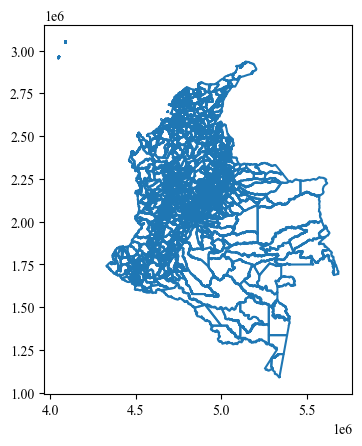

In [ ]:
shape_municipios = gpd.read_file(os.path.join(path_shape_municipios, 'MGN_MPIO_POLITICO.shp'))
shape_municipios = shape_municipios.to_crs(epsg=9377)


shape_municipios.boundary.plot()

# Geodataframe

El DataFrame se convertirá en un GeoDataFrame para reproyectar las coordenadas. Luego, las coordenadas transformadas se devolverán al DataFrame “plano” para continuar con el análisis exploratorio (EDA).

In [ ]:
gdf_unido = gpd.GeoDataFrame(
    df_unido, geometry=gpd.points_from_xy(df_unido.Longitud, df_unido.Latitud), crs="EPSG:4326"
)

<Axes: >

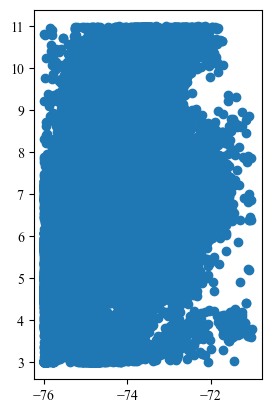

In [ ]:
gdf_unido.plot()

<Axes: >

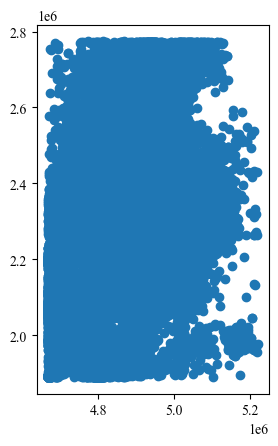

In [ ]:
gdf_unido = gdf_unido.to_crs(9377)

gdf_unido.plot()

## Obtener X y Y

In [ ]:
gdf_unido.get_coordinates()

,x,y
0,4.904854e+06,2.142823e+06
1,4.906662e+06,2.242279e+06
2,4.977023e+06,2.303426e+06
3,4.986964e+06,2.299666e+06
4,4.981444e+06,2.310165e+06
...,...,...
303235,4.804315e+06,2.082345e+06
303236,4.824225e+06,2.107278e+06
303237,4.892376e+06,2.345084e+06
303238,5.002410e+06,2.665783e+06


In [ ]:
df_unido['X [m]'] = gdf_unido.get_coordinates()['x']
df_unido['Y [m]'] = gdf_unido.get_coordinates()['y']

df_unido.head()

,Fecha-Hora UTC,Latitud,Longitud,Profundidad [km],Magnitud,Tipo Magnitud,Error Latitud [km],Error Longitud [km],Error Profundidad [km],Numero de Fases,RMS [seg],Gap,Departamento,Municipio,Catalogo,X [m],Y [m]
0,2012-01-01 01:13:29,5.292,-73.859,137.0,1.2,Ml,3.3,5.6,7.8,4,0.2,165,CUNDINAMARCA,SUTATAUSA,SGC 1,4.904854e+06,2.142823e+06
1,2012-01-01 01:14:33,6.192,-73.844,84.0,1.0,Ml,3.2,3.3,7.8,4,0.2,124,SANTANDER,LANDAZURI,SGC 1,4.906662e+06,2.242279e+06
2,2012-01-01 02:10:39,6.746,-73.208,150.3,1.2,Ml,4.9,5.2,6.6,4,0.2,226,SANTANDER,VILLANUEVA,SGC 1,4.977023e+06,2.303426e+06
3,2012-01-01 02:20:35,6.712,-73.118,140.0,1.4,Ml,6.3,8.3,8.2,5,0.3,234,SANTANDER,JORDAN,SGC 1,4.986964e+06,2.299666e+06
4,2012-01-01 02:40:37,6.807,-73.168,150.2,4.1,Ml,2.7,3.6,5.3,19,0.4,111,SANTANDER,LOS SANTOS,SGC 1,4.981444e+06,2.310165e+06


In [ ]:
df_unido.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303240 entries, 0 to 303239
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Fecha-Hora UTC          303240 non-null  object 
 1   Latitud                 303240 non-null  float64
 2   Longitud                303240 non-null  float64
 3   Profundidad [km]        303240 non-null  float64
 4   Magnitud                303240 non-null  float64
 5   Tipo Magnitud           303240 non-null  object 
 6   Error Latitud [km]      303106 non-null  float64
 7   Error Longitud [km]     303106 non-null  float64
 8   Error Profundidad [km]  303106 non-null  float64
 9   Numero de Fases         279091 non-null  object 
 10  RMS [seg]               303106 non-null  float64
 11  Gap                     303106 non-null  object 
 12  Departamento            286759 non-null  object 
 13  Municipio               285004 non-null  object 
 14  Catalogo            

# DataFrame Unido

In [ ]:
df_unido['Tiempo'] = pd.to_datetime(df_unido['Fecha-Hora UTC'])

df_unido.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303240 entries, 0 to 303239
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Fecha-Hora UTC          303240 non-null  object        
 1   Latitud                 303240 non-null  float64       
 2   Longitud                303240 non-null  float64       
 3   Profundidad [km]        303240 non-null  float64       
 4   Magnitud                303240 non-null  float64       
 5   Tipo Magnitud           303240 non-null  object        
 6   Error Latitud [km]      303106 non-null  float64       
 7   Error Longitud [km]     303106 non-null  float64       
 8   Error Profundidad [km]  303106 non-null  float64       
 9   Numero de Fases         279091 non-null  object        
 10  RMS [seg]               303106 non-null  float64       
 11  Gap                     303106 non-null  object        
 12  Departamento            286759

In [ ]:
df_unido.describe().round(2)

,Latitud,Longitud,Profundidad [km],Magnitud,Error Latitud [km],Error Longitud [km],Error Profundidad [km],RMS [seg],X [m],Y [m],Tiempo
count,303240.00,303240.00,303240.00,303240.00,303106.00,303106.00,303106.00,303106.00,303240.00,303240.00,303240
mean,6.58,-73.51,101.06,1.90,4.46,5.95,7.69,0.49,4943380.50,2285207.01,2015-07-06 19:47:00.099531520
min,3.00,-76.00,-4.97,0.00,0.00,0.00,0.00,0.00,4666612.52,1889660.69,1993-06-01 01:32:55
25%,6.42,-73.77,30.13,1.50,2.00,2.10,3.40,0.30,4915000.37,2267040.07,2011-08-20 23:17:01.750000128
50%,6.79,-73.18,136.10,1.80,3.40,4.07,6.00,0.40,4980002.58,2307954.70,2017-08-08 04:09:50.500000
75%,6.84,-73.12,145.60,2.20,5.30,7.00,8.70,0.60,4986524.34,2313368.94,2021-04-17 14:51:00.750000128
max,11.00,-71.01,594.80,6.80,999.00,999.00,999.00,10.00,5220800.48,2774223.43,2024-12-31 23:39:56
std,1.23,0.73,58.40,0.66,8.58,8.83,19.56,0.28,80623.15,136020.02,NaN


In [ ]:
df_unido['Tipo Magnitud'].unique()

array(['Ml', 'Mw', 'MLr_3', 'MLr_4', 'MLr_vmm', 'MLr_2', 'M_MLr', 'M',
       'MLr_1', 'MLr_PtoGtn', 'MLr', 'Mw(mB)', 'mb', 'mB', 'MLr_5', 'MLv',
       'Mwp', 'M_Pac', 'ML'], dtype=object)

El catalogo unido presenta diversidad de tipso de magnitudes. Se debe considerar una priorizacion de magntidudes para trabajar y realizar el análisis.

In [ ]:
total_duplicados = df_unido.duplicated(subset=['Fecha-Hora UTC', 'Latitud', 'Longitud'], keep=False).sum()
# se tiene 42396 duplicados, se debe escoger cual quedarse ...
total_eventos_df_unido = len(df_unido)
diferencia_eventos = total_eventos_df_unido - total_duplicados
porcentaje_duplicados = (total_duplicados / total_eventos_df_unido) * 100

print('Total eventos: ', total_eventos_df_unido)
print('Total duplicados: ', total_duplicados)
print('Diferencia: ', diferencia_eventos)
print('Porcentaje de duplicados: ', round(porcentaje_duplicados, 2), '%')


Total eventos:  303240
Total duplicados:  42396
Diferencia:  260844
Porcentaje de duplicados:  13.98 %


Menos del 14% de los eventos del catálogo son duplicados; por tanto, pueden eliminarse sin afectar significativamente el análisis.

In [ ]:
df_duplicados = df_unido[df_unido.duplicated(subset=['Fecha-Hora UTC', 'Latitud', 'Longitud'], keep=False)].sort_values(by=['Fecha-Hora UTC', 'Latitud', 'Longitud']).copy()
df_duplicados.reset_index(drop=True, inplace=True)

df_duplicados

,Fecha-Hora UTC,Latitud,Longitud,Profundidad [km],Magnitud,Tipo Magnitud,Error Latitud [km],Error Longitud [km],Error Profundidad [km],Numero de Fases,RMS [seg],Gap,Departamento,Municipio,Catalogo,X [m],Y [m],Tiempo
0,1993-06-03 01:10:40,4.532,-74.935,6.00,2.400,Ml,4.600,6.000,26.1,6,0.80,93,TOLIMA,ALVARADO,SGC 1,4.785397e+06,2.059068e+06,1993-06-03 01:10:40
1,1993-06-03 01:10:40,4.532,-74.935,6.00,2.400,ML,4.600,6.000,26.1,NaN,0.80,93.0,NaN,NaN,LBG,4.785397e+06,2.059068e+06,1993-06-03 01:10:40
2,1993-06-07 10:47:54,4.822,-74.630,21.20,4.600,Ml,5.300,6.100,9.4,11,0.90,92,CUNDINAMARCA,SAN JUAN DE RIOSECO,SGC 1,4.819308e+06,2.091041e+06,1993-06-07 10:47:54
3,1993-06-07 10:47:54,4.822,-74.630,21.20,4.600,ML,5.300,6.100,9.4,NaN,0.90,92.0,NaN,NaN,LBG,4.819308e+06,2.091041e+06,1993-06-07 10:47:54
4,1993-06-07 15:58:09,4.818,-74.648,6.70,2.400,Ml,3.200,3.900,13.1,5,0.40,119,CUNDINAMARCA,SAN JUAN DE RIOSECO,SGC 1,4.817311e+06,2.090603e+06,1993-06-07 15:58:09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42391,2024-02-11 06:12:53,6.861,-74.131,0.00,1.107,MLr_vmm,5.233,5.233,10.0,NaN,0.31,297,ANTIOQUIA,YONDÓ (CASABE),TECTO,4.875085e+06,2.316276e+06,2024-02-11 06:12:53
42392,2024-02-11 15:52:06,6.261,-74.475,4.70,2.100,MLr_vmm,1.061,1.061,2.7,45,0.90,58,SANTANDER,CIMITARRA,SGC 2,4.836889e+06,2.250058e+06,2024-02-11 15:52:06
42393,2024-02-11 15:52:06,6.261,-74.475,5.00,2.061,MLr_vmm,1.061,1.061,2.7,NaN,0.91,58,SANTANDER,CIMITARRA,TECTO,4.836889e+06,2.250058e+06,2024-02-11 15:52:06
42394,2024-02-12 17:51:13,6.496,-74.682,16.35,1.700,MLr_vmm,0.636,0.636,2.9,28,0.40,81,ANTIOQUIA,MACEO,SGC 2,4.814077e+06,2.276105e+06,2024-02-12 17:51:13


El catálogo SGC-2 parece más completo que TECTO: por ejemplo, incluye la columna FASE, ausente en TECTO. Además, se observan discrepancias puntuales en los valores de magnitud entre ambas fuentes.

In [ ]:
df_duplicados['Tipo Magnitud'].unique()

array(['Ml', 'ML', 'Mw', 'MLr', 'MLr_vmm', 'MLr_4', 'MLr_2', 'M_MLr',
       'MLr_3', 'M'], dtype=object)

In [ ]:
df_unido.columns

Index(['Fecha-Hora UTC', 'Latitud', 'Longitud', 'Profundidad [km]', 'Magnitud',
       'Tipo Magnitud', 'Error Latitud [km]', 'Error Longitud [km]',
       'Error Profundidad [km]', 'Numero de Fases', 'RMS [seg]', 'Gap',
       'Departamento', 'Municipio', 'Catalogo', 'X [m]', 'Y [m]', 'Tiempo'],
      dtype='object')

In [ ]:
df_unido.loc[:, 'Catalogo'].value_counts().sort_values(ascending=False)

,count
Catalogo,
SGC 1,145061
SGC 2,134030
LBG,16481
TECTO,7668


In [ ]:
df_unido.loc[:, 'Catalogo'].value_counts().sort_values(ascending=False).sum()

np.int64(303240)

Los catálogos SGC-1 y SGC-2 registran más eventos, probablemente porque incluyen parte de la Mesa de Los Santos y poseen mayor cobertura (espacial y/o en profundidad hipocentral).

In [ ]:
df_unido['Tiempo'].dt.date.min()

datetime.date(1993, 6, 1)

In [ ]:
for catalogo_ in df_unido.loc[:, 'Catalogo'].unique():
  print('--------'*3)
  print('--------'*3)
  print('Catalogo: ', catalogo_)
  df_temp = df_unido[df_unido['Catalogo'] == catalogo_].copy()
  df_temp.reset_index(drop=True, inplace=True)

  fecha_minima = df_temp['Tiempo'].dt.date.min()
  fecha_maxima = df_temp['Tiempo'].dt.date.max()
  total_dias = (fecha_maxima - fecha_minima).days
  total_eventos = len(df_temp)
  total_duplicados = df_temp.duplicated(subset=['Fecha-Hora UTC', 'Latitud', 'Longitud'], keep=False).sum()
  porcentaje_duplicados = (total_duplicados / total_eventos) * 100
  prof_minima = df_temp['Profundidad [km]'].min()
  prof_maxima = df_temp['Profundidad [km]'].max()
  tipos_magnitudes = df_temp['Tipo Magnitud'].unique()
  mag_minima = df_temp['Magnitud'].min()
  mag_maxima = df_temp['Magnitud'].max()

  print('Fecha mínima: ', fecha_minima)
  print('Fecha máxima: ', fecha_maxima)
  print('Total días: ', total_dias)
  print('Total eventos: ', total_eventos)
  print('Total duplicados: ', total_duplicados)
  print('Porcentaje de duplicados: ', round(porcentaje_duplicados, 2), '%')
  print('Profundidad mínima [km]: ', prof_minima)
  print('Profundidad máxima [km]: ', prof_maxima)
  print('Tipos de magnitudes: ', tipos_magnitudes)
  print('Magnitud mínima: ', mag_minima)
  print('Magnitud máxima: ', mag_maxima)

  del df_temp
  print('\n')

------------------------
------------------------
Catalogo:  SGC 1
Fecha mínima:  1993-06-01
Fecha máxima:  2018-02-28
Total días:  9038
Total eventos:  145061
Total duplicados:  7059
Porcentaje de duplicados:  4.87 %
Profundidad mínima [km]:  0.0
Profundidad máxima [km]:  594.8
Tipos de magnitudes:  ['Ml' 'Mw']
Magnitud mínima:  0.1
Magnitud máxima:  6.8


------------------------
------------------------
Catalogo:  SGC 2
Fecha mínima:  2018-03-01
Fecha máxima:  2024-12-31
Total días:  2497
Total eventos:  134030
Total duplicados:  0
Porcentaje de duplicados:  0.0 %
Profundidad mínima [km]:  -4.97
Profundidad máxima [km]:  319.0
Tipos de magnitudes:  ['MLr_3' 'MLr_4' 'MLr_vmm' 'MLr_2' 'M_MLr' 'M' 'MLr_1' 'MLr_PtoGtn' 'MLr'
 'Mw' 'Mw(mB)' 'mb' 'mB' 'MLr_5' 'MLv' 'Mwp' 'M_Pac']
Magnitud mínima:  0.0
Magnitud máxima:  6.1


------------------------
------------------------
Catalogo:  TECTO
Fecha mínima:  2014-02-15
Fecha máxima:  2024-02-12
Total días:  3649
Total eventos:  7668
Total du

# DataFrame Filtrado

Considerando la presencia de duplciados y que no todo el catalogo está compelto, se va proceder a eliminar los duplicados manteniendo solo el proimer evento. Esto considerando que los Catalogos SGC 1 y 2 al parecer son los mas completos, aunque presentan duplicados respecto a los catalogos de TECTO y LBG, de ser requedrido luego se procederá a ajustar el `df_filtrado`.

In [ ]:
df_filtrado = df_unido.copy()
df_filtrado.drop_duplicates(subset=['Fecha-Hora UTC', 'Latitud', 'Longitud'], keep='first', inplace=True)
df_filtrado.reset_index(drop=True, inplace=True)

df_filtrado.head()

,Fecha-Hora UTC,Latitud,Longitud,Profundidad [km],Magnitud,Tipo Magnitud,Error Latitud [km],Error Longitud [km],Error Profundidad [km],Numero de Fases,RMS [seg],Gap,Departamento,Municipio,Catalogo,X [m],Y [m],Tiempo
0,2012-01-01 01:13:29,5.292,-73.859,137.0,1.2,Ml,3.3,5.6,7.8,4,0.2,165,CUNDINAMARCA,SUTATAUSA,SGC 1,4.904854e+06,2.142823e+06,2012-01-01 01:13:29
1,2012-01-01 01:14:33,6.192,-73.844,84.0,1.0,Ml,3.2,3.3,7.8,4,0.2,124,SANTANDER,LANDAZURI,SGC 1,4.906662e+06,2.242279e+06,2012-01-01 01:14:33
2,2012-01-01 02:10:39,6.746,-73.208,150.3,1.2,Ml,4.9,5.2,6.6,4,0.2,226,SANTANDER,VILLANUEVA,SGC 1,4.977023e+06,2.303426e+06,2012-01-01 02:10:39
3,2012-01-01 02:20:35,6.712,-73.118,140.0,1.4,Ml,6.3,8.3,8.2,5,0.3,234,SANTANDER,JORDAN,SGC 1,4.986964e+06,2.299666e+06,2012-01-01 02:20:35
4,2012-01-01 02:40:37,6.807,-73.168,150.2,4.1,Ml,2.7,3.6,5.3,19,0.4,111,SANTANDER,LOS SANTOS,SGC 1,4.981444e+06,2.310165e+06,2012-01-01 02:40:37


In [ ]:
df_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 281086 entries, 0 to 281085
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Fecha-Hora UTC          281086 non-null  object        
 1   Latitud                 281086 non-null  float64       
 2   Longitud                281086 non-null  float64       
 3   Profundidad [km]        281086 non-null  float64       
 4   Magnitud                281086 non-null  float64       
 5   Tipo Magnitud           281086 non-null  object        
 6   Error Latitud [km]      280952 non-null  float64       
 7   Error Longitud [km]     280952 non-null  float64       
 8   Error Profundidad [km]  280952 non-null  float64       
 9   Numero de Fases         275561 non-null  object        
 10  RMS [seg]               280952 non-null  float64       
 11  Gap                     280952 non-null  object        
 12  Departamento            279807

In [ ]:
df_filtrado[df_filtrado['Error Latitud [km]'].isna()]

,Fecha-Hora UTC,Latitud,Longitud,Profundidad [km],Magnitud,Tipo Magnitud,Error Latitud [km],Error Longitud [km],Error Profundidad [km],Numero de Fases,RMS [seg],Gap,Departamento,Municipio,Catalogo,X [m],Y [m],Tiempo
58762,1994-02-21 07:04:03,6.54,-73.26,150.0,2.6,Ml,NaN,NaN,NaN,11,NaN,NaN,SANTANDER,PALMAR,SGC 1,4.971267e+06,2.280666e+06,1994-02-21 07:04:03
59374,1994-06-13 11:36:08,4.60,-73.79,0.0,1.7,Ml,NaN,NaN,NaN,0,NaN,NaN,CUNDINAMARCA,CHOACHI,SGC 1,4.912406e+06,2.066344e+06,1994-06-13 11:36:08
59410,1994-06-20 10:50:42,6.70,-73.57,125.0,2.5,Ml,NaN,NaN,NaN,0,NaN,NaN,SANTANDER,EL CARMEN,SGC 1,4.937028e+06,2.298375e+06,1994-06-20 10:50:42
59430,1994-06-23 14:19:22,6.73,-73.17,150.0,3.1,Ml,NaN,NaN,NaN,0,NaN,NaN,SANTANDER,VILLANUEVA,SGC 1,4.981220e+06,2.301657e+06,1994-06-23 14:19:22
59431,1994-06-23 18:19:25,6.83,-73.06,150.0,4.4,Ml,NaN,NaN,NaN,0,NaN,NaN,SANTANDER,LOS SANTOS,SGC 1,4.993373e+06,2.312704e+06,1994-06-23 18:19:25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97742,1995-06-30 08:42:03,7.81,-75.46,0.0,3.0,Ml,NaN,NaN,NaN,0,NaN,NaN,CORDOBA,MONTELIBANO,SGC 1,4.728814e+06,2.421789e+06,1995-06-30 08:42:03
97743,1995-06-30 15:05:31,6.82,-73.08,150.0,3.6,Ml,NaN,NaN,NaN,0,NaN,NaN,SANTANDER,LOS SANTOS,SGC 1,4.991164e+06,2.311599e+06,1995-06-30 15:05:31
97744,1995-06-30 17:31:42,6.94,-74.51,7.0,3.1,Ml,NaN,NaN,NaN,0,NaN,NaN,ANTIOQUIA,REMEDIOS,SGC 1,4.833246e+06,2.325124e+06,1995-06-30 17:31:42
97745,1995-06-30 19:08:03,6.27,-74.32,6.0,2.6,Ml,NaN,NaN,NaN,0,NaN,NaN,ANTIOQUIA,PUERTO BERRIO,SGC 1,4.854036e+06,2.251007e+06,1995-06-30 19:08:03


In [ ]:
df_filtrado[df_filtrado['Error Latitud [km]'].isna()].loc[:, 'Catalogo'].value_counts()

,count
Catalogo,
SGC 1,134


Algunos eventos no reportan errores de localización y, por su formato, parecen provenir del catálogo SGC-1. Dado que son pocos y cuentan con coordenadas válidas, se conservarán en el análisis.

In [ ]:
df_filtrado.describe().round(2)

,Latitud,Longitud,Profundidad [km],Magnitud,Error Latitud [km],Error Longitud [km],Error Profundidad [km],RMS [seg],X [m],Y [m],Tiempo
count,281086.00,281086.00,281086.00,281086.00,280952.00,280952.00,280952.00,280952.00,281086.00,281086.00,281086
mean,6.58,-73.47,106.61,1.91,4.46,6.05,7.35,0.50,4947836.35,2284614.83,2015-08-06 12:41:22.378137088
min,3.00,-76.00,-4.97,0.00,0.00,0.00,0.00,0.00,4666612.52,1889660.69,1993-06-01 01:32:55
25%,6.54,-73.70,62.00,1.50,2.09,2.18,3.40,0.30,4923091.88,2280697.52,2011-07-24 20:23:13.249999872
50%,6.79,-73.18,138.00,1.80,3.50,4.20,6.10,0.40,4980671.67,2308063.05,2017-10-14 19:12:13.500000
75%,6.83,-73.12,146.00,2.20,5.40,7.21,8.70,0.60,4987076.76,2313039.48,2021-06-27 06:10:59.750000128
max,11.00,-71.01,594.80,6.80,313.47,283.69,832.90,10.00,5220800.48,2774223.43,2024-12-31 23:39:56
std,1.21,0.72,55.74,0.64,4.88,7.01,8.22,0.28,79483.07,133966.62,NaN


In [ ]:
df_filtrado['X [km]'] = df_filtrado['X [m]'] / 1000
df_filtrado['Y [km]'] = df_filtrado['Y [m]'] / 1000

In [ ]:
df_filtrado.columns

Index(['Fecha-Hora UTC', 'Latitud', 'Longitud', 'Profundidad [km]', 'Magnitud',
       'Tipo Magnitud', 'Error Latitud [km]', 'Error Longitud [km]',
       'Error Profundidad [km]', 'Numero de Fases', 'RMS [seg]', 'Gap',
       'Departamento', 'Municipio', 'Catalogo', 'X [m]', 'Y [m]', 'Tiempo',
       'X [km]', 'Y [km]'],
      dtype='object')

### Histograma errores

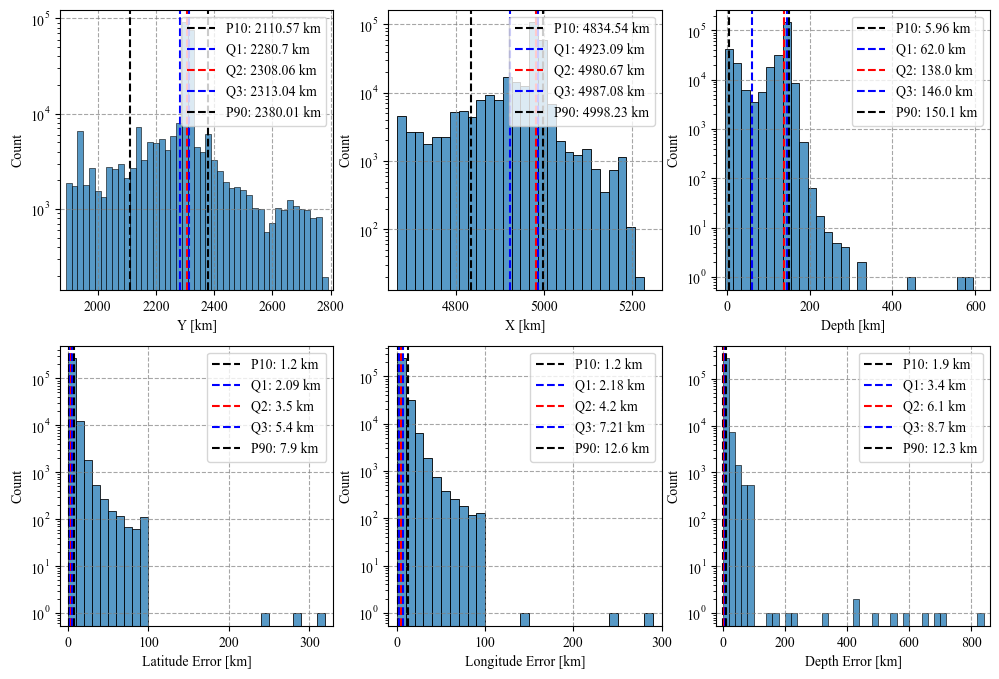

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12,8))

sup.plots.histograma_plot(df= df_filtrado,
                          columna= 'Y [km]',
                          ax_h= ax[0,0],
                          dist_min= df_filtrado['Y [km]'].min(),
                          step_= 20)

sup.plots.histograma_plot(df= df_filtrado,
                          columna= 'X [km]',
                          ax_h= ax[0,1],
                          dist_min= df_filtrado['X [km]'].min(),
                          step_= 20)

sup.plots.histograma_plot(df= df_filtrado,
                          columna= 'Profundidad [km]',
                          ax_h= ax[0,2],
                          dist_min= df_filtrado['Profundidad [km]'].min(),
                          step_= 20)

sup.plots.histograma_plot(df= df_filtrado,
                          columna= 'Error Latitud [km]',
                          ax_h= ax[1,0],
                          dist_min= 0,
                          step_= 10)

sup.plots.histograma_plot(df= df_filtrado,
                          columna= 'Error Longitud [km]',
                          ax_h= ax[1,1],
                          dist_min= 0,
                          step_= 10)

sup.plots.histograma_plot(df= df_filtrado,
                          columna= 'Error Profundidad [km]',
                          ax_h= ax[1,2],
                          dist_min= 0,
                          step_= 20)

ax[0,2].set_xlabel('Depth [km]')
ax[1,0].set_xlabel('Latitude Error [km]')
ax[1,1].set_xlabel('Longitude Error [km]')
ax[1,2].set_xlabel('Depth Error [km]')

sup.plots.save_plot(path_save_figuras = path_save_figures,
                    file_name = 'hitograma_errores_df_filtrado',
                    formato = 'png',
                    dpi_ = 300)

plt.show()

### Tiempo vs magnitud

In [ ]:
df_filtrado.columns

Index(['Fecha-Hora UTC', 'Latitud', 'Longitud', 'Profundidad [km]', 'Magnitud',
       'Tipo Magnitud', 'Error Latitud [km]', 'Error Longitud [km]',
       'Error Profundidad [km]', 'Numero de Fases', 'RMS [seg]', 'Gap',
       'Departamento', 'Municipio', 'Catalogo', 'X [m]', 'Y [m]', 'Tiempo',
       'X [km]', 'Y [km]'],
      dtype='object')

<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-3311839605.py:10: SyntaxWarning: invalid escape sequence '\l'
  label_s= f'{filtro_datos.sum()} Earthquakes [Depth $\leq50$ km]')


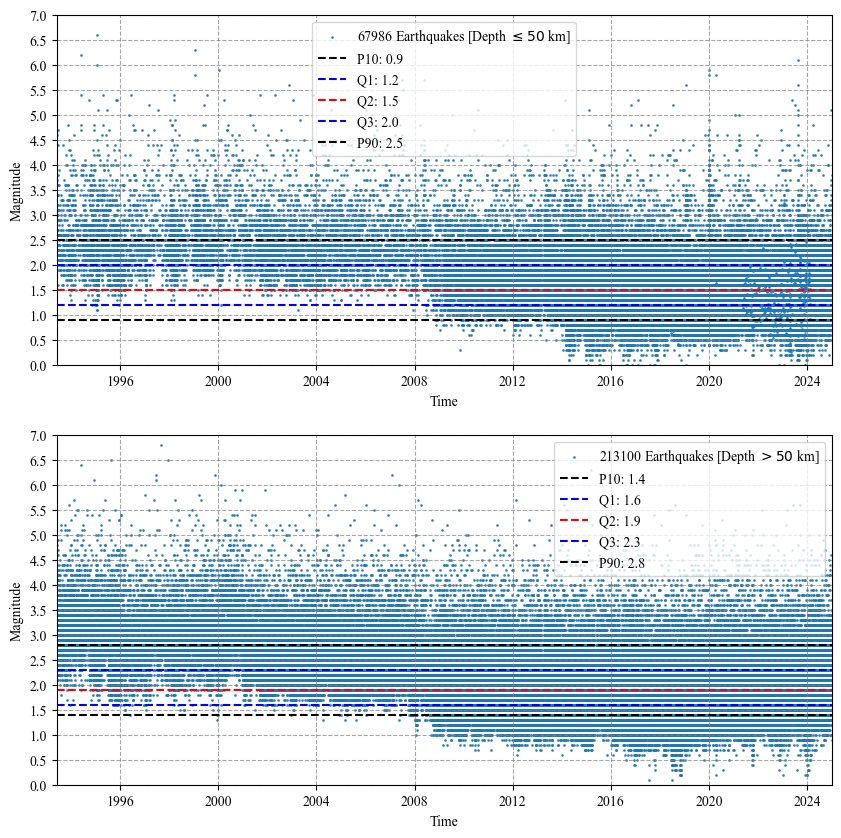

In [ ]:
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(10,10))

filtro_datos = df_filtrado['Profundidad [km]'] <= 50

sup.plots.time_magnitud_plot(df = df_filtrado,
                             filtro_datos = filtro_datos,
                             columna_eje_x_tiempo = 'Tiempo',
                             comlumna_eje_y = 'Magnitud',
                             ax_s = ax[0],
                             label_s= f'{filtro_datos.sum()} Earthquakes [Depth $\leq50$ km]')
ax[0].legend()
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Magnitude')
#ax[0].set_title()
#plt.ight_layout()

filtro_datos = df_filtrado['Profundidad [km]'] > 50

sup.plots.time_magnitud_plot(df = df_filtrado,
                             filtro_datos = filtro_datos,
                             columna_eje_x_tiempo = 'Tiempo',
                             comlumna_eje_y = 'Magnitud',
                             ax_s = ax[1],
                             label_s= f'{filtro_datos.sum()} Earthquakes [Depth $>50$ km]')
ax[1].legend()
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Magnitude')
#ax[0].set_title()

sup.plots.save_plot(path_save_figuras = path_save_figures,
                    file_name = 'scatter_tiempo_magnitud',
                    formato = 'png',
                    dpi_ = 300)

plt.show()

### Corte

In [ ]:
df_filtrado.columns

Index(['Fecha-Hora UTC', 'Latitud', 'Longitud', 'Profundidad [km]', 'Magnitud',
       'Tipo Magnitud', 'Error Latitud [km]', 'Error Longitud [km]',
       'Error Profundidad [km]', 'Numero de Fases', 'RMS [seg]', 'Gap',
       'Departamento', 'Municipio', 'Catalogo', 'X [m]', 'Y [m]', 'Tiempo',
       'X [km]', 'Y [km]'],
      dtype='object')

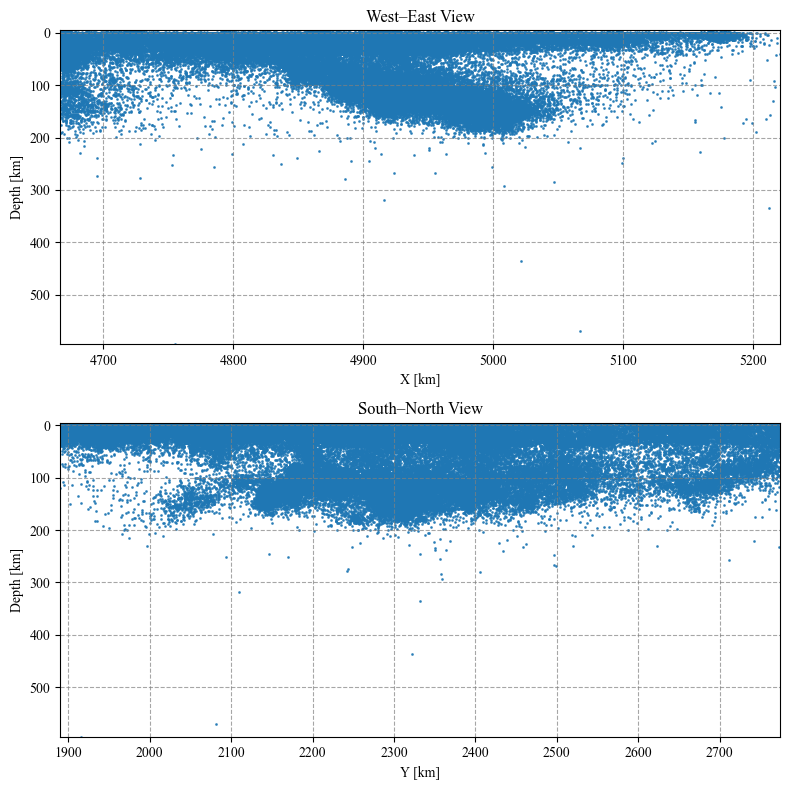

In [ ]:
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(8,8))

filtro_datos = df_filtrado['Profundidad [km]'] > -10000

sup.plots.plot_corte(df = df_filtrado,
                     columna_x = 'X [km]',
                     columna_y = 'Profundidad [km]',
                     filtro_datos = filtro_datos,
                     ax_s = ax[0],
                     label_s = 'Vista Oeste-Este',
                     invert_yaxis=True)
ax[0].set_title('West–East View')

filtro_datos = df_filtrado['Profundidad [km]'] > -10000

sup.plots.plot_corte(df = df_filtrado,
                     columna_x = 'Y [km]',
                     columna_y = 'Profundidad [km]',
                     filtro_datos = filtro_datos,
                     ax_s = ax[1],
                     label_s = 'Vista Oeste-Este',
                     invert_yaxis=True)
ax[1].set_title('South–North View')

ax[0].set_ylabel('Depth [km]')
ax[1].set_ylabel('Depth [km]')

plt.tight_layout()

sup.plots.save_plot(path_save_figuras = path_save_figures,
                    file_name = 'cortes_WE_NS',
                    formato = 'png',
                    dpi_ = 300)

plt.show()

# Punto referencia Campo Colorado



In [ ]:
punto_xy_CampoColorado = (4919222.973, 2308553.476) # x, y en metros

# se va calcular la distancia de los eventos al centroide o punto de referencia
# del Campo Colorado solo en XY mas no en profundidad

df_filtrado['Distancia [m]'] = np.sqrt((df_filtrado['X [m]'] - punto_xy_CampoColorado[0])**2 + (df_filtrado['Y [m]'] - punto_xy_CampoColorado[1])**2)
df_filtrado['Distancia [km]'] = df_filtrado['Distancia [m]'] / 1000

df_filtrado.describe().round(2)

,Latitud,Longitud,Profundidad [km],Magnitud,Error Latitud [km],Error Longitud [km],Error Profundidad [km],RMS [seg],X [m],Y [m],Tiempo,X [km],Y [km],Distancia [m],Distancia [km]
count,281086.00,281086.00,281086.00,281086.00,280952.00,280952.00,280952.00,280952.00,281086.00,281086.00,281086,281086.00,281086.00,281086.00,281086.00
mean,6.58,-73.47,106.61,1.91,4.46,6.05,7.35,0.50,4947836.35,2284614.83,2015-08-06 12:41:22.378137088,4947.84,2284.61,122479.14,122.48
min,3.00,-76.00,-4.97,0.00,0.00,0.00,0.00,0.00,4666612.52,1889660.69,1993-06-01 01:32:55,4666.61,1889.66,1091.10,1.09
25%,6.54,-73.70,62.00,1.50,2.09,2.18,3.40,0.30,4923091.88,2280697.52,2011-07-24 20:23:13.249999872,4923.09,2280.70,62947.77,62.95
50%,6.79,-73.18,138.00,1.80,3.50,4.20,6.10,0.40,4980671.67,2308063.05,2017-10-14 19:12:13.500000,4980.67,2308.06,70454.22,70.45
75%,6.83,-73.12,146.00,2.20,5.40,7.21,8.70,0.60,4987076.76,2313039.48,2021-06-27 06:10:59.750000128,4987.08,2313.04,149181.45,149.18
max,11.00,-71.01,594.80,6.80,313.47,283.69,832.90,10.00,5220800.48,2774223.43,2024-12-31 23:39:56,5220.80,2774.22,516596.81,516.60
std,1.21,0.72,55.74,0.64,4.88,7.01,8.22,0.28,79483.07,133966.62,NaN,79.48,133.97,103224.07,103.22


In [ ]:
print('Distancia mínima [km]: ', df_filtrado['Distancia [km]'].min())
print('Distancia mínima [km]: ', df_filtrado['Distancia [km]'].max())

Distancia mínima [km]:  1.0911001616484282
Distancia mínima [km]:  516.596809005253


In [ ]:
df_filtrado['Distancia [km]'].min()

1.0911001616484282

### Histograma 2D - Mapa

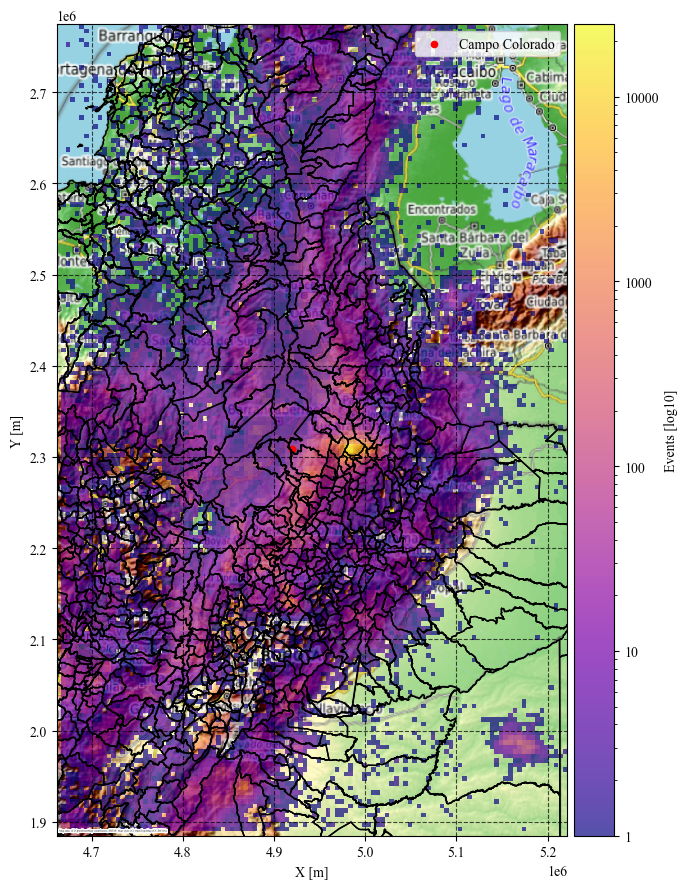

In [ ]:
x_min = df_filtrado['X [m]'].min()
x_max = df_filtrado['X [m]'].max()
y_min = df_filtrado['Y [m]'].min()
y_max = df_filtrado['Y [m]'].max()

steps_ = 5 * 1000 # m
bins_x = np.arange(start=int(x_min)-steps_, stop=int(x_max)+steps_, step=steps_)
bins_y = np.arange(start=int(y_min)-steps_, stop=int(y_max)+steps_, step=steps_)

# Datos y bins (usa los tuyos: bins_x, bins_y)
x = df_filtrado['X [m]'].to_numpy()
y = df_filtrado['Y [m]'].to_numpy()

x_min, x_max = bins_x[0], bins_x[-1]
y_min, y_max = bins_y[0], bins_y[-1]

fig, ax = plt.subplots(figsize=(7,9))

# hist2d con conteos en log (evita log(0) con vmin/cmin=1)
H = ax.hist2d(
    x, y,
    bins=[bins_x, bins_y],
    cmap='plasma', # rampa naranja
    norm=LogNorm(vmin=1), # escala log (base indiferente; la etiqueta la ponemos base-10)
    cmin=1, # descarta bins con 0 para evitar log(0)
    shading='auto',
    alpha= 0.7
)

# Barra de color en LOG10 (ticks en potencias de 10)
cb = fig.colorbar(H[3], ax=ax, pad=0.01)
cb.locator = LogLocator(base=10) # ticks en 1, 10, 100, ...
cb.formatter = LogFormatter(base=10, labelOnlyBase=False)
cb.update_ticks()
cb.set_label('Events [log10]')

# Limites y overlays (usa los tuyos)
ax.set_xlim(bins_x[0], bins_x[-1])
ax.set_ylim(bins_y[0], bins_y[-1])

# Bordes de municipios encima del histograma
shape_municipios.boundary.plot(ax=ax,
                               edgecolor='black',
                               lw=1)

ax.scatter(x=punto_xy_CampoColorado[0],
            y=punto_xy_CampoColorado[1],
            label='Campo Colorado',
            c='r',
            s=20)

ax.legend()

# Mapa base debajo (ajusta zorder)
cx.add_basemap(ax=ax,
               crs='epsg:9377',
               source=xyz.OpenTopoMap,
               reset_extent=True,
               attribution_size=2,
               zorder=0)

ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
#ax.set_title('Histograma 2D (escala log10)')
ax.grid(ls='--', c='k', alpha=0.7)

plt.tight_layout()

sup.plots.save_plot(path_save_figuras = path_save_figures,
                    file_name = 'histograma_2D_mapa',
                    formato = 'png',
                    dpi_ = 300)

plt.show()

## Filtro 50 km

Se aplicará un filtro por profundidad para diferenciar ambos catálogos a partir de los 50 km.

In [ ]:
# Diferenciar entre eventos menores a los 50 km y mayores a 50 km
profundidad_interes = 50 # km
filtro_prof_mayor = df_filtrado['Profundidad [km]'] > profundidad_interes
filtro_prof_menor_igual = df_filtrado['Profundidad [km]'] <= profundidad_interes


## Histograma Distancia

In [ ]:
step_ = 5 # km
dist_min = 0
dist_max = step_ * (1 + int(df_filtrado['Distancia [km]'].max() // step_) )

new_bins = np.arange(start=dist_min, stop=dist_max+step_, step=step_)

new_bins

array([  0,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
        65,  70,  75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125,
       130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190,
       195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255,
       260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320,
       325, 330, 335, 340, 345, 350, 355, 360, 365, 370, 375, 380, 385,
       390, 395, 400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450,
       455, 460, 465, 470, 475, 480, 485, 490, 495, 500, 505, 510, 515,
       520])

<>:15: SyntaxWarning: invalid escape sequence '\g'
<>:15: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipython-input-16616256.py:15: SyntaxWarning: invalid escape sequence '\g'
  label= f'Depth $\geq{profundidad_interes}$ km',


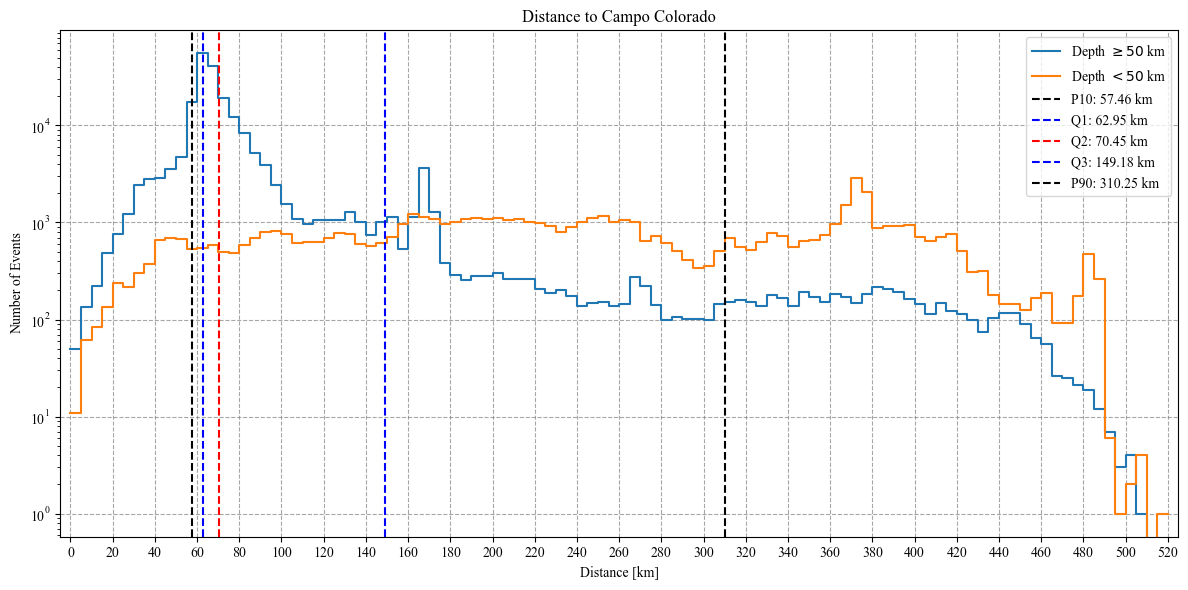

In [ ]:
p10 = df_filtrado['Distancia [km]'].quantile(q=0.1).round(2)
p25 = df_filtrado['Distancia [km]'].quantile(q=0.25).round(2) # q1
p50 = df_filtrado['Distancia [km]'].quantile(q=0.5).round(2) # q2
p75 = df_filtrado['Distancia [km]'].quantile(q=0.75).round(2) # q3
p90 = df_filtrado['Distancia [km]'].quantile(q=0.9).round(2)

fig, ax = plt.subplots(figsize=(12,6))

sns.histplot(data = df_filtrado[filtro_prof_mayor],
             x = 'Distancia [km]',
             #log_scale = (False, True),
             bins = new_bins,
             ax= ax,
             legend= True,
             label= f'Depth $\geq{profundidad_interes}$ km',
             element='step',
             fill=False)

sns.histplot(data = df_filtrado[filtro_prof_menor_igual],
             x = 'Distancia [km]',
             #log_scale = (False, True),
             bins = new_bins,
             ax= ax,
             legend= True,
             label= f'Depth $<{profundidad_interes}$ km',
             element='step',
             fill=False)

# quantiles
ax.axvline(x=p10, label=f'P10: {p10} km', c='k', ls='--')
ax.axvline(x=p25, label=f'Q1: {p25} km', c='b', ls='--')
ax.axvline(x=p50, label=f'Q2: {p50} km', c='r', ls='--')
ax.axvline(x=p75, label=f'Q3: {p75} km', c='b', ls='--')
ax.axvline(x=p90, label=f'P90: {p90} km', c='k', ls='--')


ax.set_xlim(left=dist_min-step_, right=dist_max+step_)
ax.set_xticks(np.arange(start=dist_min, stop=dist_max+step_, step=step_*4))
ax.set_xlabel('Distance [km]')
ax.set_ylabel('Number of Events')
ax.grid(ls='--', c='gray', alpha=0.7)
ax.set_yscale('log')
ax.set_title('Distance to Campo Colorado')
ax.legend()

plt.tight_layout()

sup.plots.save_plot(path_save_figuras = path_save_figures,
                    file_name = 'hitograma_distancia_campo_colorado',
                    formato = 'png',
                    dpi_ = 300)

plt.show()

## Centrado al (0,0)

Se restará el punto de referencia a las coordenadas de todos los eventos, de modo que el punto central quede en (0, 0).

In [ ]:
df_filtrado['X [m] centrado'] = df_filtrado['X [m]'] - punto_xy_CampoColorado[0]
df_filtrado['Y [m] centrado'] = df_filtrado['Y [m]'] - punto_xy_CampoColorado[1]

df_filtrado.head()

,Fecha-Hora UTC,Latitud,Longitud,Profundidad [km],Magnitud,Tipo Magnitud,Error Latitud [km],Error Longitud [km],Error Profundidad [km],Numero de Fases,...,Catalogo,X [m],Y [m],Tiempo,X [km],Y [km],Distancia [m],Distancia [km],X [m] centrado,Y [m] centrado
0,2012-01-01 01:13:29,5.292,-73.859,137.0,1.2,Ml,3.3,5.6,7.8,4,...,SGC 1,4.904854e+06,2.142823e+06,2012-01-01 01:13:29,4904.854080,2142.822926,166352.277759,166.352278,-14368.892642,-165730.550110
1,2012-01-01 01:14:33,6.192,-73.844,84.0,1.0,Ml,3.2,3.3,7.8,4,...,SGC 1,4.906662e+06,2.242279e+06,2012-01-01 01:14:33,4906.662243,2242.278544,67454.714766,67.454715,-12560.730283,-66274.931904
2,2012-01-01 02:10:39,6.746,-73.208,150.3,1.2,Ml,4.9,5.2,6.6,4,...,SGC 1,4.977023e+06,2.303426e+06,2012-01-01 02:10:39,4977.023137,2303.426239,58027.127143,58.027127,57800.163725,-5127.236862
3,2012-01-01 02:20:35,6.712,-73.118,140.0,1.4,Ml,6.3,8.3,8.2,5,...,SGC 1,4.986964e+06,2.299666e+06,2012-01-01 02:20:35,4986.964161,2299.665873,68321.724563,68.321725,67741.188086,-8887.602819
4,2012-01-01 02:40:37,6.807,-73.168,150.2,4.1,Ml,2.7,3.6,5.3,19,...,SGC 1,4.981444e+06,2.310165e+06,2012-01-01 02:40:37,4981.444110,2310.165142,62242.006659,62.242007,62221.137301,1611.665567


## Histograma 2D centrado

In [ ]:
x_ticks_ = np.arange(start= (50 * np.floor(x_min/50)),
                     stop= (50 * np.floor(x_max/50)) + 50,
                     step=50)

x_ticks_

array([4661600., 4661650., 4661700., ..., 5221500., 5221550., 5221600.])

<>:50: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-1226689585.py:50: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_title(f'Depth $\leq{profundidad_interes}$ km')


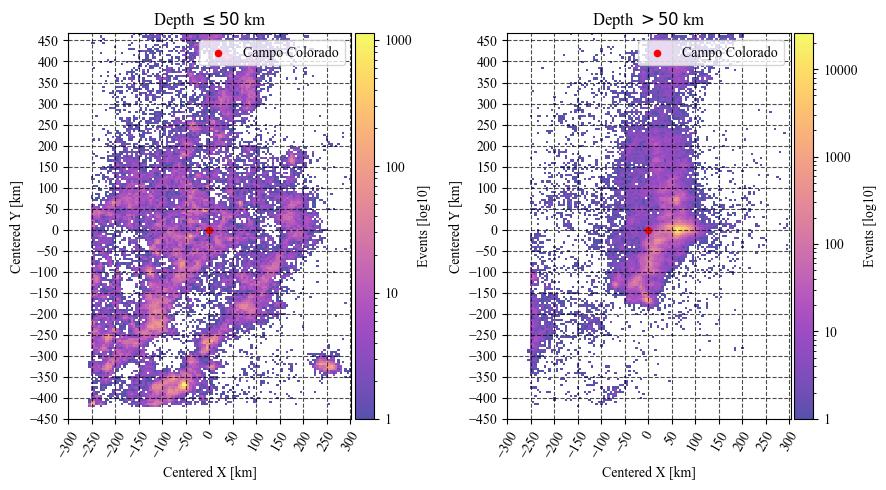

In [ ]:
x_min = df_filtrado['X [m] centrado'].min() / 1000
x_max = df_filtrado['X [m] centrado'].max() / 1000
y_min = df_filtrado['Y [m] centrado'].min() / 1000
y_max = df_filtrado['Y [m] centrado'].max() / 1000

x_ticks_ = np.arange(start= (50 * np.floor(x_min/50)),
                     stop= (50 * np.floor(x_max/50)) + 50,
                     step=50)

y_ticks_ = np.arange(start= (50 * np.floor(y_min/50)),
                     stop= (50 * np.floor(y_max/50)) + 50,
                     step=50)

steps_ = 5 # km
bins_x = np.arange(start=int(x_min)-steps_, stop=int(x_max)+steps_, step=steps_)
bins_y = np.arange(start=int(y_min)-steps_, stop=int(y_max)+steps_, step=steps_)

x_min, x_max = bins_x[0], bins_x[-1]
y_min, y_max = bins_y[0], bins_y[-1]


fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(9,5))

### Axis 0
# Datos y bins (usa los tuyos: bins_x, bins_y)
x = df_filtrado['X [m] centrado'][filtro_prof_menor_igual].to_numpy() / 1000
y = df_filtrado['Y [m] centrado'][filtro_prof_menor_igual].to_numpy() / 1000

# hist2d con conteos en log (evita log(0) con vmin/cmin=1)
H = ax[0].hist2d(
    x, y,
    bins=[bins_x, bins_y],
    cmap='plasma', # rampa naranja
    norm=LogNorm(vmin=1), # escala log (base indiferente; la etiqueta la ponemos base-10)
    cmin=1, # descarta bins con 0 para evitar log(0)
    shading='auto',
    alpha= 0.7
)

# Barra de color en LOG10 (ticks en potencias de 10)
cb = fig.colorbar(H[3], ax=ax[0], pad=0.01)
cb.locator = LogLocator(base=10) # ticks en 1, 10, 100, ...
cb.formatter = LogFormatter(base=10, labelOnlyBase=False)
cb.update_ticks()
cb.set_label('Events [log10]')

# Limites y overlays (usa los tuyos)
ax[0].set_xlim(x_min, x_max)
ax[0].set_ylim(y_min, y_max)
ax[0].set_title(f'Depth $\leq{profundidad_interes}$ km')

ax[0].scatter(x=0,
            y=0,
            label='Campo Colorado',
            c='r',
            s=20)

ax[0].legend()

ax[0].set_xlabel('Centered X [km]')
ax[0].set_ylabel('Centered Y [km]')
#ax.set_title('Histograma 2D (escala log10)')
ax[0].grid(ls='--', c='k', alpha=0.7)
ax[0].set_xticks(x_ticks_)
ax[0].set_yticks(y_ticks_)
ax[0].tick_params(axis='x', labelrotation=60)

### Axis 1
# Datos y bins (usa los tuyos: bins_x, bins_y)
x = df_filtrado['X [m] centrado'][filtro_prof_mayor].to_numpy() / 1000
y = df_filtrado['Y [m] centrado'][filtro_prof_mayor].to_numpy() / 1000

# hist2d con conteos en log (evita log(0) con vmin/cmin=1)
H = ax[1].hist2d(
    x, y,
    bins=[bins_x, bins_y],
    cmap='plasma', # rampa naranja
    norm=LogNorm(vmin=1), # escala log (base indiferente; la etiqueta la ponemos base-10)
    cmin=1, # descarta bins con 0 para evitar log(0)
    shading='auto',
    alpha= 0.7
)

# Barra de color en LOG10 (ticks en potencias de 10)
cb = fig.colorbar(H[3], ax=ax[1], pad=0.01)
cb.locator = LogLocator(base=10) # ticks en 1, 10, 100, ...
cb.formatter = LogFormatter(base=10, labelOnlyBase=False)
cb.update_ticks()
cb.set_label('Events [log10]')

# Limites y overlays (usa los tuyos)
ax[1].set_xlim(x_min, x_max)
ax[1].set_ylim(y_min, y_max)
ax[1].set_title(f'Depth $>{profundidad_interes}$ km')

ax[1].scatter(x=0,
            y=0,
            label='Campo Colorado',
            c='r',
            s=20)

ax[1].legend()

ax[1].set_xlabel('Centered X [km]')
ax[1].set_ylabel('Centered Y [km]')
#ax.set_title('Histograma 2D (escala log10)')
ax[1].grid(ls='--', c='k', alpha=0.7)
ax[1].set_xticks(x_ticks_)
ax[1].set_yticks(y_ticks_)
ax[1].tick_params(axis='x', labelrotation=60)


plt.tight_layout()

sup.plots.save_plot(path_save_figuras = path_save_figures,
                    file_name = 'histograma_2D_mapa_centrado',
                    formato = 'png',
                    dpi_ = 300)

plt.show()

<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-66574439.py:47: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_title(f'Depth $\leq{profundidad_interes}$ km')


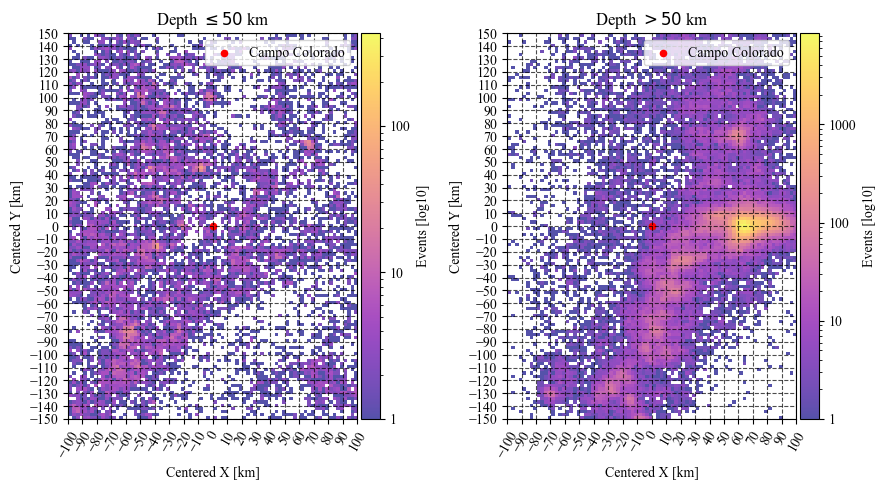

In [ ]:
x_min = df_filtrado['X [m] centrado'].min() / 1000
x_max = df_filtrado['X [m] centrado'].max() / 1000
y_min = df_filtrado['Y [m] centrado'].min() / 1000
y_max = df_filtrado['Y [m] centrado'].max() / 1000

x_ticks_ = np.arange(start= (10 * np.floor(x_min/10)),
                     stop= (10 * np.floor(x_max/10)) + 10,
                     step=10)

y_ticks_ = np.arange(start= (10 * np.floor(y_min/10)),
                     stop= (10 * np.floor(y_max/10)) + 10,
                     step=10)

steps_ = 2.5 # km
bins_x = np.arange(start=int(x_min)-steps_, stop=int(x_max)+steps_, step=steps_)
bins_y = np.arange(start=int(y_min)-steps_, stop=int(y_max)+steps_, step=steps_)

x_min, x_max = -100, 100 #bins_x[0], bins_x[-1]
y_min, y_max = -150, 150 #bins_y[0], bins_y[-1]


fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(9,5))

### Axis 0
# Datos y bins (usa los tuyos: bins_x, bins_y)
x = df_filtrado['X [m] centrado'][filtro_prof_menor_igual].to_numpy() / 1000
y = df_filtrado['Y [m] centrado'][filtro_prof_menor_igual].to_numpy() / 1000

# hist2d con conteos en log (evita log(0) con vmin/cmin=1)
H = ax[0].hist2d(
    x, y,
    bins=[bins_x, bins_y],
    cmap='plasma', # rampa naranja
    norm=LogNorm(vmin=1), # escala log (base indiferente; la etiqueta la ponemos base-10)
    cmin=1, # descarta bins con 0 para evitar log(0)
    shading='auto',
    alpha= 0.7
)

# Barra de color en LOG10 (ticks en potencias de 10)
cb = fig.colorbar(H[3], ax=ax[0], pad=0.01)
cb.locator = LogLocator(base=10) # ticks en 1, 10, 100, ...
cb.formatter = LogFormatter(base=10, labelOnlyBase=False)
cb.update_ticks()
cb.set_label('Events [log10]')

ax[0].set_title(f'Depth $\leq{profundidad_interes}$ km')

ax[0].scatter(x=0,
            y=0,
            label='Campo Colorado',
            c='r',
            s=20)

ax[0].legend()

ax[0].set_xlabel('Centered X [km]')
ax[0].set_ylabel('Centered Y [km]')
#ax.set_title('Histograma 2D (escala log10)')
ax[0].grid(ls='--', c='k', alpha=0.7)
ax[0].set_xticks(x_ticks_)
ax[0].set_yticks(y_ticks_)
ax[0].tick_params(axis='x', labelrotation=60)

### Axis 1
# Datos y bins (usa los tuyos: bins_x, bins_y)
x = df_filtrado['X [m] centrado'][filtro_prof_mayor].to_numpy() / 1000
y = df_filtrado['Y [m] centrado'][filtro_prof_mayor].to_numpy() / 1000

# hist2d con conteos en log (evita log(0) con vmin/cmin=1)
H = ax[1].hist2d(
    x, y,
    bins=[bins_x, bins_y],
    cmap='plasma', # rampa naranja
    norm=LogNorm(vmin=1), # escala log (base indiferente; la etiqueta la ponemos base-10)
    cmin=1, # descarta bins con 0 para evitar log(0)
    shading='auto',
    alpha= 0.7
)

# Barra de color en LOG10 (ticks en potencias de 10)
cb = fig.colorbar(H[3], ax=ax[1], pad=0.01)
cb.locator = LogLocator(base=10) # ticks en 1, 10, 100, ...
cb.formatter = LogFormatter(base=10, labelOnlyBase=False)
cb.update_ticks()
cb.set_label('Events [log10]')

ax[1].set_title(f'Depth $>{profundidad_interes}$ km')

ax[1].scatter(x=0,
            y=0,
            label='Campo Colorado',
            c='r',
            s=20)

ax[1].legend()

ax[1].set_xlabel('Centered X [km]')
ax[1].set_ylabel('Centered Y [km]')
#ax.set_title('Histograma 2D (escala log10)')
ax[1].grid(ls='--', c='k', alpha=0.7)
ax[1].set_xticks(x_ticks_)
ax[1].set_yticks(y_ticks_)
ax[1].tick_params(axis='x', labelrotation=60)

# Limites y overlays (usa los tuyos)
ax[0].set_xlim(x_min, x_max)
ax[0].set_ylim(y_min, y_max)

ax[1].set_xlim(x_min, x_max)
ax[1].set_ylim(y_min, y_max)

plt.tight_layout()

sup.plots.save_plot(path_save_figuras = path_save_figures,
                    file_name = 'histograma_2D_mapa_centrado_zoom',
                    formato = 'png',
                    dpi_ = 300)

plt.show()

# Fin